<a href="https://colab.research.google.com/github/phhien203/ML-foundations/blob/master/TSLA_Evaluate_a_Forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluate a Forecast: Tesla (TSLA)

This notebook evaluates one-trading-day-ahead forecasts for Tesla using three models: **Naive (no change)**, **Ridge Regression**, and **XGBoost**. Models predict the next log return; predictions are converted back to prices for evaluation. Six chronological walk-forward folds are used to avoid look-ahead bias.

## 1. Setup
Run the installation cell once. In Google Colab, restart the runtime only if requested.

In [1]:
%pip install -q yfinance pandas numpy matplotlib scikit-learn xgboost

In [2]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
OUTPUT_DIR = Path('tsla_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42

## 2. Download and inspect approximately ten years of TSLA data
`auto_adjust=True` makes historical prices consistent across stock splits. The end date is exclusive.

In [3]:
START_DATE = '2016-10-08'
END_DATE = '2026-10-09'

raw = yf.download('TSLA', start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
raw = raw.sort_index().dropna(how='all')
if raw.empty:
    raise RuntimeError('No TSLA data was downloaded. Check the internet connection and try again.')
print(f'Rows: {len(raw):,} | {raw.index.min().date()} to {raw.index.max().date()}')
display(raw.head())
display(raw.tail())

Rows: 2,513 | 2016-10-10 to 2026-10-08


Price,Close,High,Low,Open,Volume
Date,,,,,
2016-10-10,13.396667,13.609333,13.310667,13.423333,49744500
2016-10-11,13.340000,13.480000,13.220667,13.456667,34926000
2016-10-12,13.434000,13.592000,13.361333,13.396667,29560500
2016-10-13,13.349333,13.393333,13.136667,13.366667,37419000
2016-10-14,13.100667,13.428667,13.086667,13.377333,64048500


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-10-02,370.589996,374.600006,359.410004,360.079987,55330100
2026-10-05,378.730011,381.589996,364.910004,369.000000,42232700
2026-10-06,380.679993,383.329987,378.519989,381.980011,27735400
2026-10-07,377.809998,382.350006,374.429993,378.450012,25529400
2026-10-08,373.239990,375.959991,371.553986,374.119995,12057329


## 3. Feature engineering
All features on row *t* use information available by the close of day *t*. The target is the log return on the next trading day.

In [4]:
df = raw.copy()
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
for lag in [1, 2, 3, 5, 10, 20]:
    df[f'return_lag_{lag}'] = df['log_return'].shift(lag - 1)
for window in [5, 10, 20, 60]:
    df[f'return_mean_{window}'] = df['log_return'].rolling(window).mean()
    df[f'return_vol_{window}'] = df['log_return'].rolling(window).std()
    df[f'price_ma_ratio_{window}'] = df['Close'] / df['Close'].rolling(window).mean() - 1
df['range_pct'] = (df['High'] - df['Low']) / df['Close']
df['volume_change'] = np.log(df['Volume'].replace(0, np.nan)).diff()
df['target_return'] = df['log_return'].shift(-1)
df['target_price'] = df['Close'].shift(-1)

FEATURES = [c for c in df.columns if c.startswith(('return_lag_', 'return_mean_', 'return_vol_', 'price_ma_ratio_'))]
FEATURES += ['range_pct', 'volume_change']
data = df.dropna(subset=FEATURES + ['target_return', 'target_price']).copy()
print(f'Model-ready rows: {len(data):,}; features: {len(FEATURES)}')

Model-ready rows: 2,452; features: 20


## 4. Walk-forward validation design
The final 1,500 observations are divided into six non-overlapping test folds of 250 trading days. Each fold trains only on earlier data.

In [5]:
N_FOLDS = 6
TEST_SIZE = 250
required = N_FOLDS * TEST_SIZE + 250
if len(data) < required:
    raise ValueError(f'Need at least {required} model-ready rows; found {len(data)}.')
first_test = len(data) - N_FOLDS * TEST_SIZE
folds = []
for fold in range(N_FOLDS):
    test_start = first_test + fold * TEST_SIZE
    test_end = test_start + TEST_SIZE
    train_idx = np.arange(0, test_start)
    test_idx = np.arange(test_start, test_end)
    folds.append((train_idx, test_idx))
    print(f'Fold {fold + 1}: train through {data.index[train_idx[-1]].date()}, test {data.index[test_idx[0]].date()} to {data.index[test_idx[-1]].date()}')

Fold 1: train through 2020-10-15, test 2020-10-16 to 2021-10-13
Fold 2: train through 2021-10-13, test 2021-10-14 to 2022-10-11
Fold 3: train through 2022-10-11, test 2022-10-12 to 2023-10-10
Fold 4: train through 2023-10-10, test 2023-10-11 to 2024-10-08
Fold 5: train through 2024-10-08, test 2024-10-09 to 2025-10-08
Fold 6: train through 2025-10-08, test 2025-10-09 to 2026-10-07


## Figure 1 — Price history and validation folds

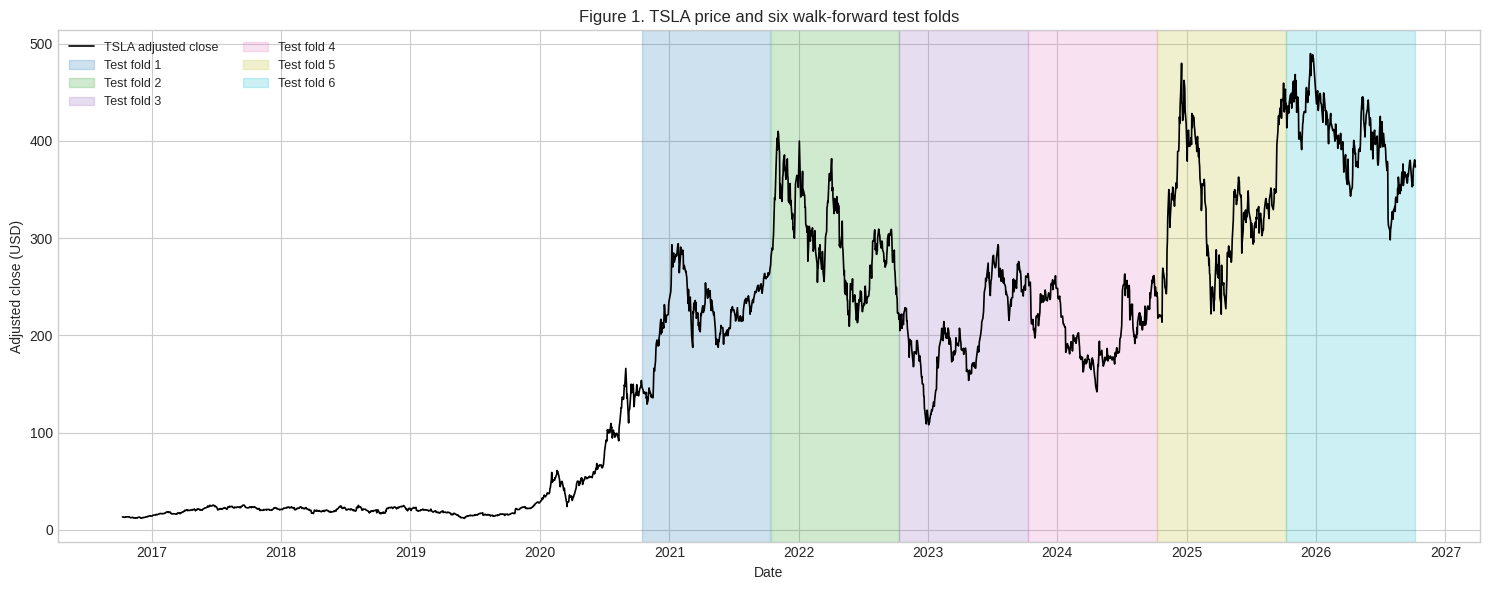

In [6]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(raw.index, raw['Close'], color='black', lw=1.2, label='TSLA adjusted close')
colors = plt.cm.tab10(np.linspace(0, 1, N_FOLDS))
for i, (_, test_idx) in enumerate(folds):
    ax.axvspan(data.index[test_idx[0]], data.index[test_idx[-1]], color=colors[i], alpha=0.22, label=f'Test fold {i + 1}')
ax.set(title='Figure 1. TSLA price and six walk-forward test folds', xlabel='Date', ylabel='Adjusted close (USD)')
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_1_walk_forward_folds.png', dpi=180)
plt.show()

## 5. Train and evaluate all models
Naive predicts zero next-day return, which means tomorrow's price equals today's price. Ridge scaling is fitted inside each training fold. XGBoost uses fixed hyperparameters to avoid tuning on test data.

In [7]:
prediction_frames = []
metric_rows = []

for fold_no, (train_idx, test_idx) in enumerate(folds, start=1):
    train, test = data.iloc[train_idx], data.iloc[test_idx]
    X_train, y_train = train[FEATURES], train['target_return']
    X_test = test[FEATURES]

    ridge = make_pipeline(StandardScaler(), Ridge(alpha=10.0))
    xgb = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8, objective='reg:squarederror', random_state=RANDOM_STATE, n_jobs=-1)
    ridge.fit(X_train, y_train)
    xgb.fit(X_train, y_train)

    return_predictions = {
        'Naive': np.zeros(len(test)),
        'Ridge': ridge.predict(X_test),
        'XGBoost': xgb.predict(X_test),
    }
    fold_predictions = pd.DataFrame(index=test.index)
    fold_predictions['fold'] = fold_no
    fold_predictions['Actual'] = test['target_price']
    for model_name, predicted_return in return_predictions.items():
        predicted_price = test['Close'].to_numpy() * np.exp(predicted_return)
        fold_predictions[model_name] = predicted_price
        mae = mean_absolute_error(test['target_price'], predicted_price)
        rmse = mean_squared_error(test['target_price'], predicted_price) ** 0.5
        mape = np.mean(np.abs((test['target_price'].to_numpy() - predicted_price) / test['target_price'].to_numpy())) * 100
        direction_actual = np.sign(test['target_return'].to_numpy())
        direction_pred = np.sign(predicted_return)
        direction_accuracy = np.mean(direction_actual == direction_pred) * 100
        metric_rows.append({'fold': fold_no, 'model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE_pct': mape, 'direction_accuracy_pct': direction_accuracy})
    prediction_frames.append(fold_predictions)

predictions = pd.concat(prediction_frames).sort_index()
metrics = pd.DataFrame(metric_rows)
naive_mae = metrics.loc[metrics['model'] == 'Naive', ['fold', 'MAE']].rename(columns={'MAE': 'naive_MAE'})
metrics = metrics.merge(naive_mae, on='fold')
metrics['MAE_over_Naive'] = metrics['MAE'] / metrics['naive_MAE']
display(metrics.round(4))
metrics.to_csv(OUTPUT_DIR / 'fold_metrics.csv', index=False)
predictions.to_csv(OUTPUT_DIR / 'predictions.csv')

,fold,model,MAE,RMSE,MAPE_pct,direction_accuracy_pct,naive_MAE,MAE_over_Naive
0,1,Naive,5.3224,7.3284,2.4126,0.0,5.3224,1.0000
1,1,Ridge,5.4740,7.5216,2.4795,47.6,5.3224,1.0285
2,1,XGBoost,5.4378,7.4770,2.4596,54.0,5.3224,1.0217
3,2,Naive,9.4013,12.5076,3.1634,0.0,9.4013,1.0000
4,2,Ridge,9.6498,12.7696,3.2513,48.0,9.4013,1.0264
5,2,XGBoost,9.8173,13.0612,3.2984,52.4,9.4013,1.0442
6,3,Naive,5.5845,7.3651,2.8232,0.4,5.5845,1.0000
7,3,Ridge,5.5863,7.3916,2.8298,56.0,5.5845,1.0003
8,3,XGBoost,5.6938,7.5108,2.9086,55.6,5.5845,1.0196
9,4,Naive,5.3010,7.2075,2.5548,0.0,5.3010,1.0000


## Figure 2 — Actual versus predicted prices

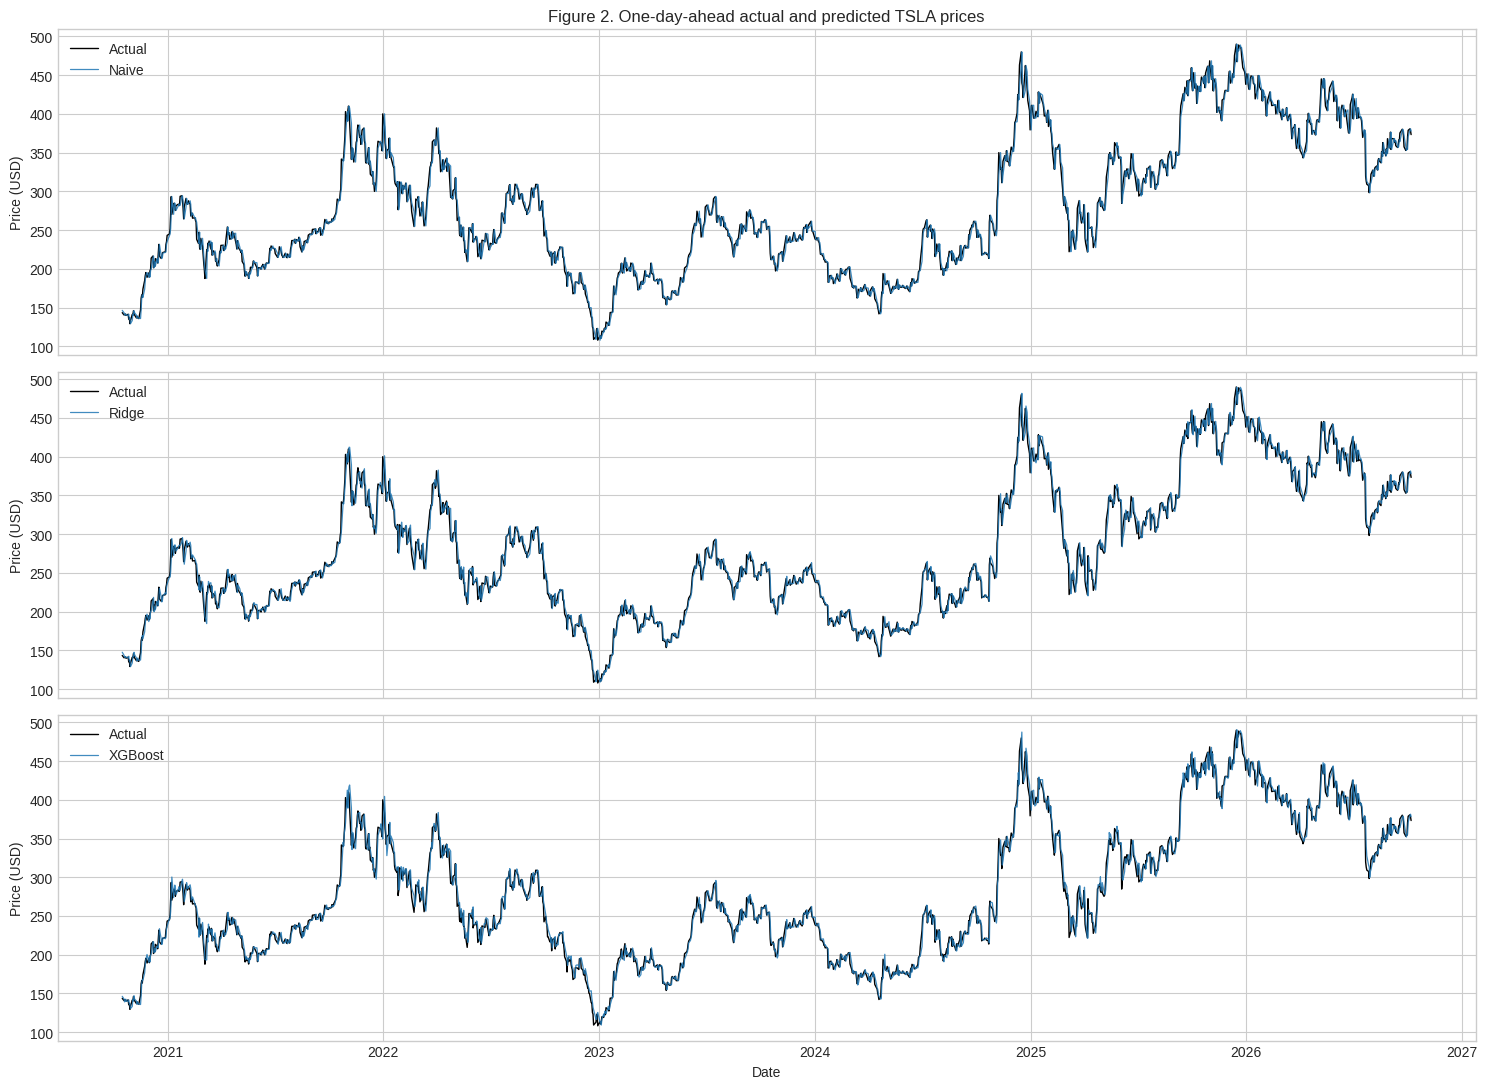

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)
for ax, model in zip(axes, ['Naive', 'Ridge', 'XGBoost']):
    ax.plot(predictions.index, predictions['Actual'], color='black', lw=1, label='Actual')
    ax.plot(predictions.index, predictions[model], lw=0.9, alpha=0.85, label=model)
    ax.set_ylabel('Price (USD)')
    ax.legend(loc='upper left')
axes[0].set_title('Figure 2. One-day-ahead actual and predicted TSLA prices')
axes[-1].set_xlabel('Date')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_2_actual_vs_predictions.png', dpi=180)
plt.show()

## Figures 3 and 4 — Relative error by fold and overall stability
A value below 1.0 means the model beats Naive; above 1.0 means it is worse.

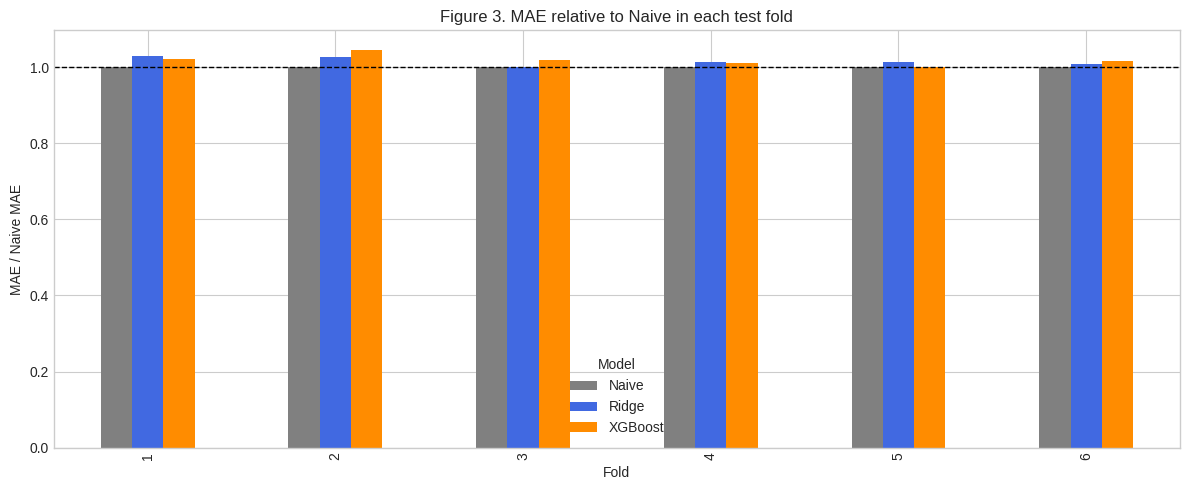

,MAE_mean,MAE_std,MAE_over_Naive_mean,MAE_over_Naive_std,direction_accuracy_mean
model,,,,,
Naive,7.4496,2.2944,1.0000,0.0000,0.0667
Ridge,7.5629,2.3413,1.0149,0.0108,49.6667
XGBoost,7.5917,2.3368,1.0190,0.0144,53.8667


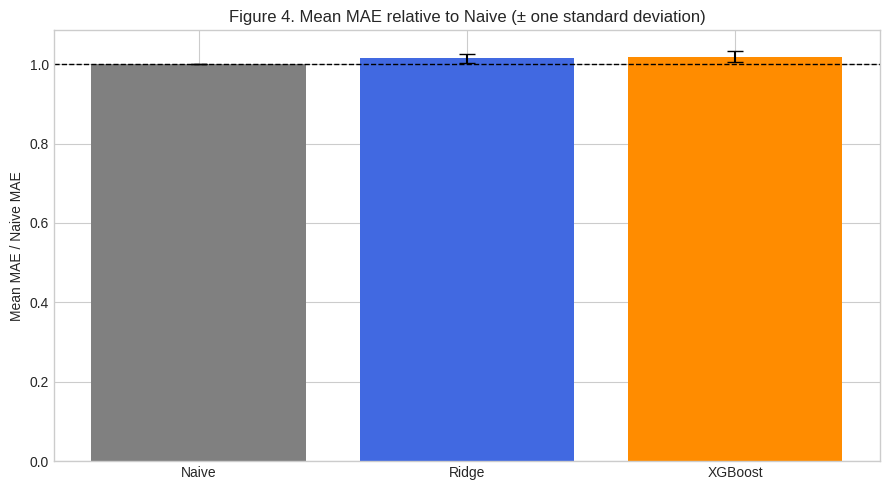

In [9]:
ratio_table = metrics.pivot(index='fold', columns='model', values='MAE_over_Naive')[['Naive', 'Ridge', 'XGBoost']]
ax = ratio_table.plot(kind='bar', figsize=(12, 5), color=['gray', 'royalblue', 'darkorange'])
ax.axhline(1.0, color='black', ls='--', lw=1)
ax.set(title='Figure 3. MAE relative to Naive in each test fold', xlabel='Fold', ylabel='MAE / Naive MAE')
ax.legend(title='Model')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_3_mae_ratio_by_fold.png', dpi=180)
plt.show()

summary = metrics.groupby('model').agg(MAE_mean=('MAE', 'mean'), MAE_std=('MAE', 'std'), MAE_over_Naive_mean=('MAE_over_Naive', 'mean'), MAE_over_Naive_std=('MAE_over_Naive', 'std'), direction_accuracy_mean=('direction_accuracy_pct', 'mean')).reindex(['Naive', 'Ridge', 'XGBoost'])
display(summary.round(4))
summary.to_csv(OUTPUT_DIR / 'model_summary.csv')

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(summary))
ax.bar(x, summary['MAE_over_Naive_mean'], yerr=summary['MAE_over_Naive_std'], capsize=6, color=['gray', 'royalblue', 'darkorange'])
ax.axhline(1.0, color='black', ls='--', lw=1)
ax.set_xticks(x, summary.index)
ax.set(title='Figure 4. Mean MAE relative to Naive (± one standard deviation)', ylabel='Mean MAE / Naive MAE')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_4_mean_mae_ratio.png', dpi=180)
plt.show()

## 6. Recommendation template
Use the computed tables and figures rather than assuming the advanced model wins. A model is practically useful only if it beats Naive consistently, has reasonably low variation across folds, and improves the decision metric enough to justify its complexity and trading costs.

In [10]:
best_model = summary['MAE_over_Naive_mean'].idxmin()
best_ratio = summary.loc[best_model, 'MAE_over_Naive_mean']
if best_model == 'Naive' or best_ratio >= 1:
    recommendation = 'Neither machine-learning model improves on the Naive benchmark on average. Do not deploy the ML forecast for investment decisions.'
else:
    improvement = (1 - best_ratio) * 100
    recommendation = f'{best_model} has the lowest average MAE, improving on Naive by {improvement:.2f}%. Review fold stability, directional accuracy, and transaction costs before deployment.'
print(recommendation)

Neither machine-learning model improves on the Naive benchmark on average. Do not deploy the ML forecast for investment decisions.
